SCENARIO 2 – BOOSTING (Churn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

AdaBoost: 1.0
Gradient Boosting: 1.0


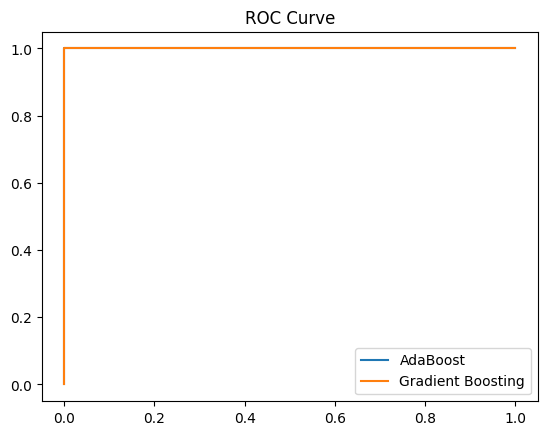

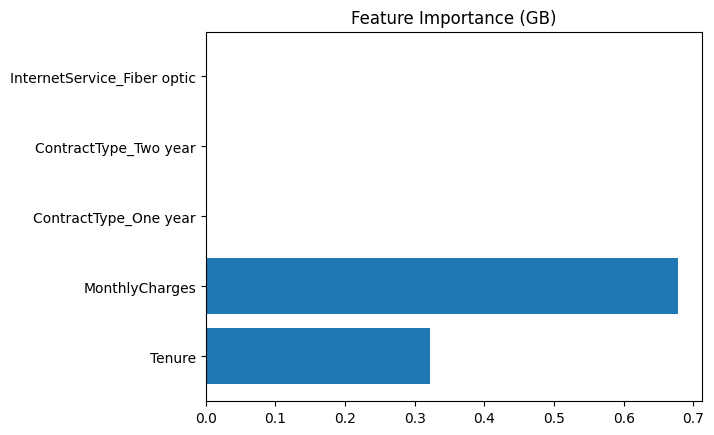

In [2]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

df = pd.read_csv("churn_boosting.csv")

# Convert categorical
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# AdaBoost
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# Accuracy
print("AdaBoost:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))

# ROC Curve
for model, name in [(ada, "AdaBoost"), (gb, "Gradient Boosting")]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance (GB)
importances = gb.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance (GB)")
plt.show()